# 03 - Feature Engineering
## Airbnb Price Prediction - Austin, TX

**Purpose of this notebook**  
Transform the cleaned dataset into a feature-rich version ready for preprocessing.
Every feature is built on a clear business hypothesis, stated in the markdown cell
that precedes its creation.

**What this notebook does NOT do**
- No encoding or scaling (handled in `04_Preprocessing.ipynb`)
- No model training (handled in `05_Modeling_Linear.ipynb` and beyond)
- No use of the test set (not yet created)

**Input**  
`../data/processed/data_cleaned.parquet` (produced by `02_Cleaning.ipynb`)

**Output**  
`../data/processed/data_features.parquet`

**Anti-leakage discipline**  
No feature uses information that would not be available at the moment a listing is
created. In particular, review-based features are flagged as such and will be
handled with care during preprocessing.

**Outline**
1. Imports and Setup
2. Load Data
3. Geographic Features
4. Property Features
5. Host Features
7. Final Report and Export

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.neighbors import BallTree

pd.set_option('display.max_columns', None)

INPUT_PATH = '../data/processed/Austin/data_cleaned.parquet'
OUTPUT_PATH = '../data/processed/Austin/data_features.parquet'

# Austin downtown reference point (Congress Ave Bridge area)
DOWNTOWN_LAT = 30.2672
DOWNTOWN_LON = -97.7431

## 2. Load Data

We load the cleaned dataset produced by `02_Cleaning.ipynb` and run a quick sanity
check: shape, column types, and presence of the columns we will need to build
features in the next sections (`latitude`, `longitude`, `accommodates`, `bedrooms`,
`bathrooms_clean`, `amenities`, `host_since`, `number_of_reviews`).

In [2]:
df = pd.read_parquet(INPUT_PATH)

print(f"Shape: {df.shape}")
print(f"\nDtypes summary:\n{df.dtypes.value_counts()}")

required_cols = [
    'latitude', 'longitude', 'accommodates', 'bedrooms',
    'bathrooms_clean', 'amenities', 'host_since', 'number_of_reviews'
]
missing_cols = [c for c in required_cols if c not in df.columns]
print(f"\nRequired columns missing: {missing_cols if missing_cols else 'none'}")

df.head(3)

Shape: (10516, 49)

Dtypes summary:
int64      16
float64    16
str        13
bool        4
Name: count, dtype: int64

Required columns missing: ['number_of_reviews']


,scrape_id,last_scraped,source,host_id,host_name,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,availability_eoy,number_of_reviews_ly,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,bathrooms_clean
0,20250916040734,2025-09-17,city scrape,8028,Sylvia,2009-02-16,"Austin, TX",within a few hours,100.0,90.0,True,East Downtown,1.0,2.0,"['email', 'phone']",True,True,78702,30.26057,-97.73441,Entire guesthouse,Entire home/apt,3,1.0,2.0,"[""Iron"", ""Private entrance"", ""Hot water"", ""Dis...",97.0,2,90,2.0,4.0,90.0,90.0,2.1,90.0,t,13,35,65,328,2025-09-17,81,33,False,1,1,0,0,1.0
1,20250916040734,2025-09-17,city scrape,14156,Amy,2009-04-20,"Austin, TX",within an hour,100.0,96.0,True,Zilker,1.0,2.0,"['email', 'phone']",True,True,78704,30.26034,-97.76487,Entire guesthouse,Entire home/apt,2,1.0,2.0,"[""Private patio or balcony"", ""Stove"", ""Cleanin...",160.0,3,365,3.0,3.0,1125.0,1125.0,3.0,1125.0,t,12,30,50,316,2025-09-17,61,20,True,1,1,0,0,1.0
2,20250916040734,2025-09-17,city scrape,25298,Karen,2009-07-11,"Austin, TX",within a day,100.0,60.0,False,East Riverside,1.0,1.0,"['email', 'phone']",True,False,78741,30.23466,-97.73682,Entire guest suite,Entire home/apt,2,1.0,1.0,"[""Wifi"", ""Smoke alarm"", ""Shampoo"", ""Heating"", ...",38.0,4,90,3.0,14.0,90.0,90.0,6.0,90.0,t,29,59,88,88,2025-09-17,88,2,False,1,1,0,0,1.0


## 3. Geographic Features

Location is one of the strongest price drivers identified in the EDA (3x spread
across ZIP codes). We build three complementary geographic features:

1. `distance_to_downtown_km`: distance to Austin downtown (Congress Ave Bridge)
2. `geo_cluster`: k-means clusters on (lat, lon) to capture micro-neighborhoods
3. `listings_density_500m`: number of other listings within a 500m radius

These three features are intentionally redundant in different ways:
`neighbourhood_cleansed` is administrative, `geo_cluster` is data-driven,
`listings_density_500m` is hyper-local. Each captures a different signal.

### 3.1 Distance to Downtown

**Diagnosis**  
Austin is a monocentric city: tourist demand concentrates around downtown
(6th Street, Rainey Street, the Capitol, Lady Bird Lake). A listing 2 km from
downtown commands a very different price from one 20 km out, even within the
same neighborhood.

We compute the great-circle distance (haversine formula) from each listing
to the downtown reference point (lat=30.2672, lon=-97.7431). Haversine is
required rather than Euclidean because latitude and longitude are angles on
a sphere, not Cartesian coordinates.

**Action**  
Vectorized haversine computation over the whole dataframe, result in kilometers.

In [3]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

df['distance_to_downtown_km'] = haversine_km(
    df['latitude'], df['longitude'], DOWNTOWN_LAT, DOWNTOWN_LON
)

print(df['distance_to_downtown_km'].describe().round(2))
print(f"\nMissing values: {df['distance_to_downtown_km'].isnull().sum()}")

count    10516.00
mean         7.42
std          6.34
min          0.11
25%          2.67
50%          5.21
75%         10.68
max         30.00
Name: distance_to_downtown_km, dtype: float64

Missing values: 0


### 3.2 Geographic Clusters

**Diagnosis**  
`neighbourhood_cleansed` is an administrative partition: its boundaries follow
city districts, not the actual spatial structure of the Airbnb market. Two
listings on opposite sides of a neighborhood boundary may be 200m apart but
end up in different categories, while two listings 5 km apart inside a large
neighborhood end up in the same one.

We complement it with a **data-driven** partition built by k-means on
(latitude, longitude). This produces compact spatial clusters that reflect
where listings actually concentrate, regardless of administrative borders.

**Why k-means here**  
k-means minimizes within-cluster variance, which on 2D coordinates produces
roughly circular, equally-dense zones — exactly what we want for
micro-neighborhoods. It is also fast and deterministic with a fixed seed.

**Choice of k**  
We pick `k = 20`. With ~10,500 listings, this gives an average of ~525 listings
per cluster — enough statistical mass for downstream target encoding in
notebook 04, while still capturing meaningful spatial granularity. We do not
run an elbow analysis here: the goal is not to find "true" clusters but to
provide a useful spatial bucketing feature.

**Action**  
Fit `KMeans(n_clusters=20, random_state=42)` on the two GPS columns,
store the cluster label as an integer feature.

Number of clusters: 20
Mean cluster size : 526
Min  cluster size : 142
Max  cluster size : 1670


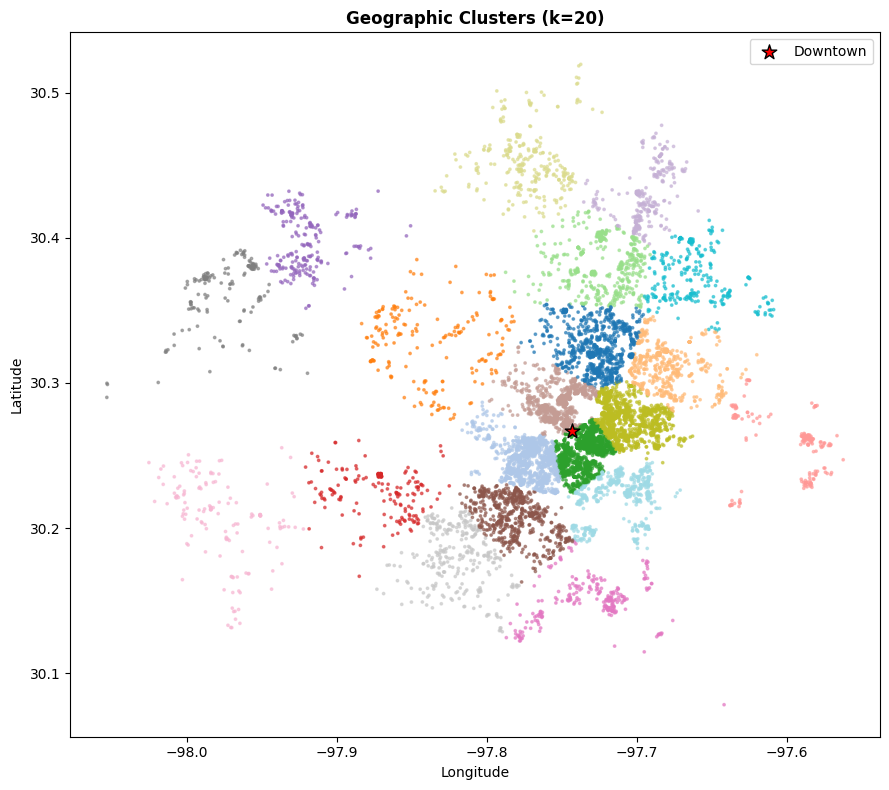

In [4]:
kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
df['geo_cluster'] = kmeans.fit_predict(df[['latitude', 'longitude']])

cluster_sizes = df['geo_cluster'].value_counts().sort_index()
print(f"Number of clusters: {df['geo_cluster'].nunique()}")
print(f"Mean cluster size : {cluster_sizes.mean():.0f}")
print(f"Min  cluster size : {cluster_sizes.min()}")
print(f"Max  cluster size : {cluster_sizes.max()}")

fig, ax = plt.subplots(figsize=(9, 8))
scatter = ax.scatter(
    df['longitude'], df['latitude'],
    c=df['geo_cluster'], cmap='tab20', s=3, alpha=0.6
)
ax.scatter(DOWNTOWN_LON, DOWNTOWN_LAT, c='red', s=120, marker='*',
           edgecolor='black', linewidth=1, label='Downtown', zorder=5)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Geographic Clusters (k=20)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 3.3 Local Listings Density

**Diagnosis**  
Two listings can sit in the same `geo_cluster` and at the same
`distance_to_downtown_km`, yet face very different micro-level competition.
A listing on a quiet residential street with no other Airbnb in 500m operates
in a different market than one on a block packed with 30 other rentals.

We capture this with `listings_density_500m`: for each listing, the number of
*other* listings within a 500m radius. This is a hyper-local signal,
complementary to the cluster-level and city-level features built above.

**Why 500m**  
500m is roughly a 6-minute walk, a meaningful "neighborhood-of-walking"
scale for a tourist choosing between two listings. Larger radii (1-2 km)
would dilute the signal into something closer to what `geo_cluster` already
captures.

**Why BallTree with haversine**  
A naive pairwise distance computation on 10,516 listings would mean ~110M
distance calculations. `BallTree` indexes points in a tree structure that
makes radius queries logarithmic rather than linear, the whole computation
runs in a fraction of a second. The haversine metric is required because
the input is (lat, lon) in radians, not Cartesian coordinates.

**Action**  
1. Convert coordinates to radians (haversine requirement)
2. Build a `BallTree` index
3. Query the radius (500m, expressed in radians as `0.5 / 6371`)
4. Subtract 1 from each count to exclude the listing itself

In [5]:
# Convert to radians
coords_rad = np.radians(df[['latitude', 'longitude']].values)

# Build the BallTree index
tree = BallTree(coords_rad, metric='haversine')

# 500m expressed in radians: distance_km / Earth_radius_km
radius_rad = 0.5 / 6371.0

# Count points within radius
counts = tree.query_radius(coords_rad, r=radius_rad, count_only=True)
df['listings_density_500m'] = counts - 1

print(df['listings_density_500m'].describe().round(2))
print(f"\nMissing values: {df['listings_density_500m'].isnull().sum()}")
print(f"Listings with no neighbor within 500m: {(df['listings_density_500m'] == 0).sum()}")

count    10516.00
mean        66.64
std         88.46
min          0.00
25%         13.00
50%         34.00
75%         80.00
max        427.00
Name: listings_density_500m, dtype: float64

Missing values: 0
Listings with no neighbor within 500m: 163


**Observations — Geographic Features**
- `distance_to_downtown_km`: median 5.2 km, range 0.1–30 km, no missing values. Distribution matches Austin's geography: most listings within a 10 km radius of downtown, long tail toward the outskirts.
- `geo_cluster`: 20 data-driven clusters, mean size ~525, min 142, max 1670. Imbalance reflects real spatial density (compact downtown clusters, sprawling suburban ones) and is expected.
- `listings_density_500m`: median 34 neighbors within 500m, max 427. The heavy right skew confirms strong micro-level clustering of supply — exactly the signal we want to expose to the model. 163 listings have no neighbor within 500m and act as a natural "isolated" group.
- All three features are complementary: `distance_to_downtown_km` is city-level, `geo_cluster` is district-level, `listings_density_500m` is street-level.

## 4. Property Features

Three features describe the physical product:

1. `guests_per_bedroom`: crowding indicator
2. `bathrooms_per_guest`: sanitary comfort indicator
3. `amenity_score`: quality signal extracted from the `amenities` column

### 4.1 Guests per Bedroom and Bathrooms per Guest

**Diagnosis**  
The raw EDA flagged strong multicollinearity between `accommodates`, `bedrooms`,
and `beds`. A linear model fed with these three columns side by side will
struggle to attribute coefficients cleanly. Ratios encode the *interaction*
between them in a single column, which is both more interpretable and easier
for a model to use.

Two ratios capture two different aspects of comfort:
- `guests_per_bedroom = accommodates / bedrooms`: how crowded the rooms are.
  A 4-guest listing with 2 bedrooms (ratio 2.0) is roomier than a 4-guest
  studio (ratio 4.0).
- `bathrooms_per_guest = bathrooms_clean / accommodates`: sanitary comfort.
  A 6-guest listing with 1 bathroom (ratio 0.17) is less comfortable than a
  6-guest listing with 3 bathrooms (ratio 0.5).

**Edge cases**  
- `bedrooms == 0` exists (studios). Dividing by zero would produce `inf`.
  We replace 0 bedrooms with 1 for the ratio computation: conceptually, a
  studio has one sleeping space.
- `accommodates == 0` should not exist after cleaning, we verify and proceed.

**Action**  
Compute the two ratios with the studio-handling rule above.

In [6]:
# Sanity check on denominators
print(f"Listings with bedrooms == 0 : {(df['bedrooms'] == 0).sum()}")
print(f"Listings with accommodates == 0 : {(df['accommodates'] == 0).sum()}")

# Ratio 1: guests per bedroom (studios treated as 1 bedroom)
effective_bedrooms = df['bedrooms'].replace(0, 1)
df['guests_per_bedroom'] = df['accommodates'] / effective_bedrooms

# Ratio 2: bathrooms per guest
df['bathrooms_per_guest'] = df['bathrooms_clean'] / df['accommodates']

# Report
print("\nguests_per_bedroom:")
print(df['guests_per_bedroom'].describe().round(2))
print("\nbathrooms_per_guest:")
print(df['bathrooms_per_guest'].describe().round(2))

Listings with bedrooms == 0 : 610
Listings with accommodates == 0 : 0

guests_per_bedroom:
count    10516.00
mean         2.54
std          1.00
min          0.20
25%          2.00
50%          2.00
75%          3.00
max         16.00
Name: guests_per_bedroom, dtype: float64

bathrooms_per_guest:
count    10516.00
mean         0.40
std          0.25
min          0.00
25%          0.25
50%          0.33
75%          0.50
max          5.75
Name: bathrooms_per_guest, dtype: float64


In [7]:
import ast
from collections import Counter

def parse_amenities(s):
    """Parse the JSON-like string into a Python list."""
    if pd.isna(s):
        return []
    try:
        return ast.literal_eval(s)
    except (ValueError, SyntaxError):
        return []

df['amenities_list'] = df['amenities'].apply(parse_amenities)

# Sanity check
print(f"Listings with empty amenity list: {(df['amenities_list'].str.len() == 0).sum()}")
print(f"Median amenities per listing    : {df['amenities_list'].str.len().median():.0f}")
print(f"Max amenities in a single listing: {df['amenities_list'].str.len().max()}")

# Frequency of each amenity across the whole dataset
all_amenities = Counter()
for lst in df['amenities_list']:
    all_amenities.update(lst)

print(f"\nUnique amenity strings across dataset: {len(all_amenities)}")
print(f"\nTop 40 most frequent amenities:")
for name, count in all_amenities.most_common(40):
    pct = count / len(df) * 100
    print(f"  {pct:5.1f}%  {name}")

Listings with empty amenity list: 2
Median amenities per listing    : 46
Max amenities in a single listing: 109

Unique amenity strings across dataset: 4479

Top 40 most frequent amenities:
   97.1%  Smoke alarm
   92.6%  Kitchen
   89.7%  Wifi
   83.9%  Hot water
   82.9%  Carbon monoxide alarm
   80.3%  Dishes and silverware
   80.3%  Hair dryer
   79.0%  Hangers
   78.5%  Fire extinguisher
   78.4%  Microwave
   78.0%  Bed linens
   77.5%  Cooking basics
   77.3%  Essentials
   76.4%  Self check-in
   76.2%  Iron
   73.8%  Refrigerator
   71.8%  Dedicated workspace
   71.4%  Shampoo
   71.3%  Free parking on premises
   67.2%  Air conditioning
   67.2%  Dishwasher
   64.9%  First aid kit
   63.1%  TV
   58.0%  Freezer
   57.6%  Extra pillows and blankets
   55.2%  Long term stays allowed
   55.2%  Bathtub
   55.1%  Wine glasses
   55.1%  Dining table
   55.0%  Heating
   54.4%  Ceiling fan
   54.2%  Washer
   54.2%  Toaster
   53.1%  Private entrance
   52.3%  Cleaning products
   5

In [8]:
print("Amenities ranked 41-100:")
for i, (name, count) in enumerate(all_amenities.most_common(100)[40:], start=41):
    pct = count / len(df) * 100
    print(f"  {i:3d}. {pct:5.1f}%  {name}")

Amenities ranked 41-100:
   41.  49.8%  Free street parking
   42.  49.4%  Outdoor furniture
   43.  47.4%  Baking sheet
   44.  47.3%  Exterior security cameras on property
   45.  46.4%  Coffee maker
   46.  41.6%  Stove
   47.  39.5%  Pets allowed
   48.  39.4%  Outdoor dining area
   49.  39.1%  Room-darkening shades
   50.  39.0%  Hot water kettle
   51.  36.6%  Blender
   52.  35.0%  BBQ grill
   53.  34.0%  Keypad
   54.  33.0%  Dryer
   55.  32.0%  Private patio or balcony
   56.  31.5%  Free dryer – In unit
   57.  30.8%  Central heating
   58.  29.4%  Luggage dropoff allowed
   59.  27.7%  Central air conditioning
   60.  26.4%  Clothing storage
   61.  25.6%  Books and reading material
   62.  25.3%  Smart lock
   63.  24.7%  Single level home
   64.  24.5%  Fire pit
   65.  23.0%  Barbecue utensils
   66.  22.4%  Free washer – In unit
   67.  22.0%  Private backyard – Fully fenced
   68.  21.4%  Board games
   69.  20.2%  Patio or balcony
   70.  18.7%  Laundromat nearby
  

In [9]:
hot_tub_variants = [a for a in all_amenities if 'hot tub' in a.lower() or 'jacuzzi' in a.lower()]
print(f"Hot tub / jacuzzi variants found: {len(hot_tub_variants)}")
for a in sorted(hot_tub_variants, key=lambda x: -all_amenities[x])[:10]:
    print(f"  {all_amenities[a]:4d}  {a}")

Hot tub / jacuzzi variants found: 19
   441  Hot tub
   244  Private hot tub
    98  Private hot tub - available all year, open 24 hours
    69  Shared hot tub
    32  Private hot tub - available all year, open specific hours
    32  Private hot tub - available all year
    15  Shared hot tub - available all year, open 24 hours
    12  Shared hot tub - available all year, open specific hours
     6  Private hot tub - available seasonally, open 24 hours
     5  Shared hot tub - available all year


### 4.2 Amenity Tier

**Diagnosis**  
The `amenities` column lists 5 to 100+ items per listing, with 4,479 unique
strings across the dataset due to orthographic variants ("Pool", "Shared pool",
"Private pool available all year", etc.). A raw count is uninformative: in
the US, basic amenities like heating, hot water, and AC are standard, and
safety items (smoke alarm, fire extinguisher) are mandated by Airbnb. What
discriminates price is the presence of **value-adding amenities**.

**Approach**  
1. Group amenities into three tiers by business value: `basic` (1 pt),
   `premium` (3 pts), `luxury` (8 pts).
2. Match by keywords (case-insensitive substring) to capture all orthographic
   variants of the same concept (e.g. "hot tub" catches "Hot tub",
   "Private hot tub", "Shared hot tub - available all year").
3. Compute a raw score per listing = sum of points across matched amenities.
4. Cut the score into three categories via fixed thresholds chosen from the
   score distribution: `basic` / `premium` / `luxury`.

**Why thresholds and not quantiles**  
Quantile cuts (33/33/33) would force every dataset to have the same proportion
in each tier, which is misleading: if Austin is overall a high-end market,
forcing 33% into "basic" would distort the signal. Fixed thresholds based on
the score distribution preserve absolute meaning.

**Excluded amenities**  
Safety items mandated by Airbnb (smoke alarm, CO alarm, fire extinguisher,
first aid kit, exterior cameras, noise monitors) are deliberately excluded:
they carry no price signal and would only add noise.

Concepts: 16 basic, 17 premium, 11 luxury
Theoretical max score: 155

Raw score distribution:
count    10516.00
mean        59.29
std         21.06
min          0.00
25%         46.00
50%         60.00
75%         73.00
max        132.00
Name: amenity_raw_score, dtype: float64


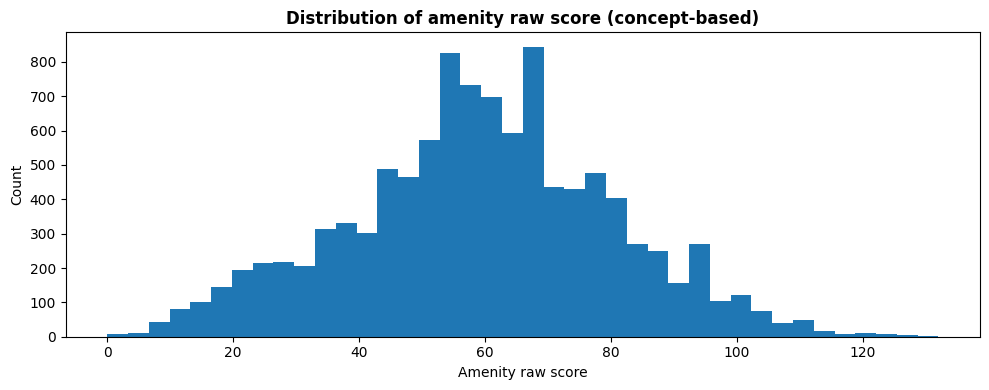

In [10]:
# Each tier is a dict {concept_name: [keywords that identify it]}.
# A listing scores points for a concept if ANY of its amenities contains
# ANY of the concept's keywords (case-insensitive). Each concept counts
# at most once per listing.

BASIC_CONCEPTS = {
    'wifi':            ['wifi'],
    'kitchen':         ['kitchen'],
    'hot_water':       ['hot water'],
    'heating':         ['heating'],
    'ac':              ['air conditioning', 'central air'],
    'bed_linens':      ['bed linens'],
    'toiletries':      ['shampoo', 'conditioner', 'body soap', 'shower gel'],
    'hair_dryer':      ['hair dryer'],
    'essentials':      ['essentials'],
    'cooking_basics':  ['cooking basics', 'dishes and silverware'],
    'microwave':       ['microwave'],
    'refrigerator':    ['refrigerator', 'mini fridge'],
    'self_checkin':    ['self check-in'],
    'long_stay':       ['long term stays allowed'],
    'iron':            ['iron'],
    'hangers':         ['hangers'],
}

PREMIUM_CONCEPTS = {
    'dishwasher':      ['dishwasher'],
    'washer':          ['washer'],
    'dryer':           ['dryer'],
    'parking':         ['parking'],
    'workspace':       ['dedicated workspace'],
    'tv':              ['tv', 'hdtv'],
    'bathtub':         ['bathtub'],
    'dining_setup':    ['dining table', 'wine glasses'],
    'coffee_maker':    ['coffee maker', 'coffee'],
    'oven':            ['oven'],
    'stove':           ['stove'],
    'outdoor_space':   ['outdoor furniture', 'outdoor dining', 'patio',
                        'balcony', 'backyard'],
    'bbq':             ['bbq', 'barbecue'],
    'fire_pit':        ['fire pit'],
    'private_entrance':['private entrance'],
    'pets_allowed':    ['pets allowed'],
    'smart_lock':      ['smart lock', 'keypad'],
}

LUXURY_CONCEPTS = {
    'pool':            ['pool'],
    'hot_tub':         ['hot tub', 'jacuzzi'],
    'gym':             ['gym', 'exercise equipment'],
    'sauna':           ['sauna'],
    'fireplace':       ['indoor fireplace'],
    'ev_charger':      ['ev charger'],
    'elevator':        ['elevator'],
    'view':            ['city skyline view', 'waterfront', 'lake view',
                        'mountain view'],
    'sound_system':    ['sound system'],
    'sun_loungers':    ['sun loungers'],
    'piano':           ['piano'],
}


def amenity_score(amenity_list):
    """Sum weighted points across concepts, each concept counted once."""
    if not amenity_list:
        return 0
    lower_items = [a.lower() for a in amenity_list]
    score = 0
    # Check luxury first, then premium, then basic. A given concept is
    # matched at most once thanks to the structure (concepts are disjoint
    # across tiers by design).
    for keywords in LUXURY_CONCEPTS.values():
        if any(kw in item for kw in keywords for item in lower_items):
            score += 8
    for keywords in PREMIUM_CONCEPTS.values():
        if any(kw in item for kw in keywords for item in lower_items):
            score += 3
    for keywords in BASIC_CONCEPTS.values():
        if any(kw in item for kw in keywords for item in lower_items):
            score += 1
    return score


df['amenity_raw_score'] = df['amenities_list'].apply(amenity_score)

print(f"Concepts: {len(BASIC_CONCEPTS)} basic, "
      f"{len(PREMIUM_CONCEPTS)} premium, {len(LUXURY_CONCEPTS)} luxury")
print(f"Theoretical max score: "
      f"{len(BASIC_CONCEPTS)*1 + len(PREMIUM_CONCEPTS)*3 + len(LUXURY_CONCEPTS)*8}")

print("\nRaw score distribution:")
print(df['amenity_raw_score'].describe().round(2))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['amenity_raw_score'], bins=40, edgecolor='none')
ax.set_xlabel('Amenity raw score')
ax.set_ylabel('Count')
ax.set_title('Distribution of amenity raw score (concept-based)',
             fontweight='bold')
plt.tight_layout()
plt.show()

**Threshold calibration**  
The raw score distribution is approximately normal, centered at 60 with a
total range of 0–132 (theoretical max: 155). We cut into three tiers using
fixed thresholds chosen from the distribution shape and a business rationale:

- `basic`   : score < 45  -> mostly basic amenities, few or no premium ones
- `premium` : 45 ≤ score < 80 -> full set of basics + several premium concepts
- `luxury`  : score ≥ 80   -> multiple luxury concepts on top of the rest

Expected split: roughly 25% basic, 55% premium, 20% luxury.

In [11]:
def assign_tier(score):
    if score < 45:
        return 'basic'
    elif score < 80:
        return 'premium'
    else:
        return 'luxury'


df['amenity_tier'] = df['amenity_raw_score'].apply(assign_tier)
df['amenity_tier'] = pd.Categorical(
    df['amenity_tier'],
    categories=['basic', 'premium', 'luxury'],
    ordered=True
)

# Distribution check
print("Tier distribution:")
print(df['amenity_tier'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')
print(f"\nTotal listings: {len(df)}")

# Quick sanity: tier vs price (median in $)
print("\nMedian price by tier (sanity check):")
print(df.groupby('amenity_tier', observed=True)['price'].median().round(0))

# Drop intermediate columns
df.drop(columns=['amenities', 'amenities_list', 'amenity_raw_score'], inplace=True)
print(f"\nColumns remaining: {df.shape[1]}")

Tier distribution:
amenity_tier
premium    60.2%
basic      22.8%
luxury     17.0%
Name: proportion, dtype: str

Total listings: 10516

Median price by tier (sanity check):
amenity_tier
basic       96.0
premium    132.0
luxury     215.0
Name: price, dtype: float64

Columns remaining: 54


**Observations — Property Features**
- `guests_per_bedroom`: median 2.0, max 16. Captures crowding independently of absolute size.
- `bathrooms_per_guest`: median 0.33 (one bathroom for three guests). Captures sanitary comfort.
- `amenity_tier`: 23% basic / 60% premium / 17% luxury. Median price increases monotonically: $96 → $132 → $215. The tier captures a real discontinuity in the market — premium-to-luxury jump (+$83) is much larger than basic-to-premium (+$36), which a categorical feature handles better than a continuous score.
- Raw `amenities` and intermediate columns dropped. The dataset now carries a clean, interpretable, model-ready signal for property quality.

## 5. Host Features

The cleaning notebook already converted host booleans (`host_is_superhost`,
`host_identity_verified`, `host_has_profile_pic`) and host rates
(`host_response_rate`, `host_acceptance_rate`) into model-ready formats.
Two host columns still need attention:

- `host_since`: currently a date string, not directly usable by a model
- `host_total_listings_count`: usable as-is, will simply be carried forward

### 5.1 Host Seniority

**Diagnosis**  
`host_since` is the date the host first joined Airbnb. As a raw date it
cannot be fed to a model. The meaningful signal is **how long** the host has
been on the platform: a 10-year veteran is presumably more polished and
trustworthy than a 6-month newcomer, and that may translate into pricing
power.

We convert `host_since` to `host_seniority_days`, computed against the
**snapshot date** (16 September 2025), not against `pd.Timestamp.now()`.
Using "now" would tie the feature to the moment the notebook is run, which
breaks reproducibility and would give inconsistent values between train and
inference time.

**Missing values**  
The cleaning notebook flagged 9 listings with missing `host_since` (0.09%).
Since this is negligible, we impute with the median seniority and proceed.

**Action**  
1. Parse `host_since` as datetime
2. Compute `host_seniority_days` = (snapshot_date − host_since).days
3. Impute missing values with the median
4. Drop the raw `host_since` column

In [12]:
SNAPSHOT_DATE = pd.Timestamp('2025-09-16')

df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
df['host_seniority_days'] = (SNAPSHOT_DATE - df['host_since']).dt.days

missing_before = df['host_seniority_days'].isnull().sum()
median_seniority = df['host_seniority_days'].median()
df['host_seniority_days'] = df['host_seniority_days'].fillna(median_seniority)

df.drop(columns=['host_since'], inplace=True)

print(f"Missing host_since imputed : {missing_before} (median used: {median_seniority:.0f} days, "
      f"{median_seniority/365:.1f} years)")
print(f"\nhost_seniority_days distribution:")
print(df['host_seniority_days'].describe().round(0))
print(f"\nIn years:")
print((df['host_seniority_days'] / 365).describe().round(1))

Missing host_since imputed : 9 (median used: 3186 days, 8.7 years)

host_seniority_days distribution:
count    10516.0
mean      2888.0
std       1425.0
min          7.0
25%       1626.0
50%       3186.0
75%       4003.0
max       6406.0
Name: host_seniority_days, dtype: float64

In years:
count    10516.0
mean         7.9
std          3.9
min          0.0
25%          4.5
50%          8.7
75%         11.0
max         17.6
Name: host_seniority_days, dtype: float64


**Observations — Host Features**
- `host_seniority_days`: range 7 days to 17.6 years (max matches Airbnb's founding era). Median 8.7 years confirms Austin is an early-adopter city for Airbnb. 9 missing values imputed with the median.
- Other host columns (`host_is_superhost`, `host_identity_verified`, `host_has_profile_pic`, `host_response_rate`, `host_acceptance_rate`, `host_total_listings_count`) are carried forward unchanged from the cleaning notebook.

## 6. Final Report and Export

Before exporting, we run a final sanity check:

1. **Feature inventory** list the features created in this notebook
2. **Missing values audit** verify no NaN was introduced during feature engineering
3. **Shape and dtypes** confirm the dataset is model-ready
4. **Export** to Parquet for the preprocessing notebook

In [13]:
NEW_FEATURES = [
    'distance_to_downtown_km',
    'geo_cluster',
    'listings_density_500m',
    'guests_per_bedroom',
    'bathrooms_per_guest',
    'amenity_tier',
    'host_seniority_days',
]

print("Features created in this notebook:")
for f in NEW_FEATURES:
    present = "OK" if f in df.columns else "MISSING"
    print(f"  [{present}] {f}")

print(f"\nFinal shape: {df.shape}")
print(f"\nDtypes summary:")
print(df.dtypes.value_counts())

# Missing values audit
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("\nMissing values: none.")
else:
    print(f"\nMissing values detected in {len(missing)} columns:")
    print(missing.sort_values(ascending=False))

# Export
df.to_parquet(OUTPUT_PATH, index=False)
print(f"\nSaved to {OUTPUT_PATH}")

Features created in this notebook:
  [OK] distance_to_downtown_km
  [OK] geo_cluster
  [OK] listings_density_500m
  [OK] guests_per_bedroom
  [OK] bathrooms_per_guest
  [OK] amenity_tier
  [OK] host_seniority_days

Final shape: (10516, 54)

Dtypes summary:
float64     20
int64       17
str         11
bool         4
int32        1
category     1
Name: count, dtype: int64

Missing values detected in 12 columns:
host_location                1858
host_response_time            851
host_neighbourhood            834
has_availability               85
host_name                       9
host_listings_count             9
host_verifications              9
host_total_listings_count       9
minimum_minimum_nights          6
maximum_minimum_nights          6
minimum_maximum_nights          6
maximum_maximum_nights          6
dtype: int64

Saved to ../data/processed/Austin/data_features.parquet
